# Packages and Libraries

In [60]:
import numpy as np
from matplotlib import pyplot as plt
import pandas as pd
import seaborn as sns  
sns.set(style="darkgrid")  


from sklearn.metrics import confusion_matrix as sk_confusion_matrix, ConfusionMatrixDisplay,roc_curve, roc_auc_score
from sklearn.preprocessing import StandardScaler
from sklearn.utils import resample

import tensorflow as tf
from tensorflow import keras
from keras import metrics
from keras.datasets import fashion_mnist
import keras_tuner as kt

plt.style.use('default') 
tf.get_logger().setLevel('INFO')

# Data Ingestion

In [24]:
#Data Ingestion
X_train = pd.read_csv("cleaned_x_train.csv")
Y_train = pd.read_csv("cleaned_y_train.csv")

X_val   = pd.read_csv("cleaned_x_val.csv")
Y_val   = pd.read_csv("cleaned_y_val.csv")

X_test  = pd.read_csv("cleaned_x_test.csv")
Y_test  = pd.read_csv("cleaned_y_test.csv")

# Data Check

In [25]:
#Shape of the data

datasets = {
    "X_train": X_train,
    "Y_train": Y_train,
    "X_val": X_val,
    "Y_val": Y_val,
    "X_test": X_test,
    "Y_test": Y_test
}

for name, arr in datasets.items():
    print(f"{name} shape: {arr.shape}")

X_train shape: (24158, 24)
Y_train shape: (24158, 1)
X_val shape: (5178, 24)
Y_val shape: (5178, 1)
X_test shape: (5177, 24)
Y_test shape: (5177, 1)


In [26]:
pd.DataFrame({
    "X_min": X_train.min(),
    "X_max": X_train.max(),
    "Y_min": Y_train.min(),
    "Y_max": Y_train.max()})

,X_min,X_max,Y_min,Y_max
ACEADNED,0.0,4.0,NaN,NaN
ACEADSAF,0.0,4.0,NaN,NaN
ACEDEPRS,0.0,1.0,NaN,NaN
ACEDIVRC,0.0,8.0,NaN,NaN
ACEDRINK,0.0,1.0,NaN,NaN
ACEDRUGS,0.0,1.0,NaN,NaN
ACEHURT1,0.0,2.0,NaN,NaN
ACEPRISN,0.0,1.0,NaN,NaN
ACEPUNCH,0.0,2.0,NaN,NaN
ACESWEAR,0.0,2.0,NaN,NaN


# Data Scaling

In [27]:
# scale some x features and convert y values to 0/1
cols_to_scale = ["ACEHURT1", "ACEPUNCH", "ACESWEAR", "ACETOUCH", "ACETTHEM",
                "ACEADNED", "ACEADSAF", "ACEDIVRC", "_SMOKER3", "_EDUCAG",
                "MENTHLTH", "PHYSHLTH", "_AGE80", "ACE_SCORE"]

scaler = StandardScaler()

X_train[cols_to_scale ] = scaler.fit_transform(X_train[cols_to_scale])
X_val[cols_to_scale]   = scaler.transform(X_val[cols_to_scale])
X_test[cols_to_scale]  = scaler.transform(X_test[cols_to_scale])

Y_train = Y_train.squeeze().astype(int)
Y_val   = Y_val.squeeze().astype(int)
Y_test  = Y_test.squeeze().astype(int)

# Baseline

In [28]:
#1 number of risky drinkers images
print("Number of Risky Drinkers:", sum(Y_train == 1))
#2 number of non-risky drinkers
print("Number of Non-Risky Drinkers:", sum(Y_train == 0))
#3 majority class in Y_train
class_counts = np.bincount(Y_train)
majority = class_counts.argmax()
if majority == 0:
    print("Majority Class: Non-Risky Drinkers")
else:
    print("Majority Class: Risky Drinkers")
#4 accuracy of majority class in Y_train
print("Accuracy of The Majority Class/ Baseline Accuracy:", class_counts.max() / len(Y_train))

Number of Risky Drinkers: 9110
Number of Non-Risky Drinkers: 15048
Majority Class: Non-Risky Drinkers
Accuracy of The Majority Class/ Baseline Accuracy: 0.6228992466263763


# Downsampling The Majority Class (Non-Risky Drinkers)

In [29]:
maj_idx = Y_train[Y_train == 0].index   
min_idx = Y_train[Y_train == 1].index 

majority_down_idx = resample(
    maj_idx,
    replace=False,
    n_samples=len(min_idx),   # match minority class size
    random_state=42
)

downsampled_idx = np.random.RandomState(42).permutation(list(majority_down_idx) + list(min_idx))

X_train_down = X_train.loc[downsampled_idx]
Y_train_down = Y_train.loc[downsampled_idx]

# Building Initial Logistic Regression Model

In [30]:
def build_model(num_features, learning_rate):
  """
  Creates a basic logistic regression model with one Dense layer and a sigmoid
  activation. All weights and the bias start at 1, and a random seed keeps the
  results consistent. The model uses SGD with the given learning rate and is
  compiled with binary cross-entropy and accuracy.
  Args:
    num_features: The number of input features.
    learning_rate: The desired learning rate for SGD.

  Returns:
    model: A tf.keras model (graph).
  """

  tf.keras.backend.clear_session()
  tf.random.set_seed(0)


  model = tf.keras.Sequential()
  model.add(tf.keras.layers.Dense(
      units=1,        
      input_shape=(num_features,),  
      use_bias=True,              
      activation="sigmoid",
      kernel_initializer=tf.keras.initializers.Ones(),  
      bias_initializer=tf.keras.initializers.Ones(),    
  ))

  optimizer = tf.keras.optimizers.SGD(learning_rate=learning_rate)


  model.compile(optimizer=optimizer,
                  loss="binary_crossentropy",
                  metrics=["accuracy"])
    
  return model

Epoch 1/5


/opt/anaconda3/envs/ml-env/lib/python3.10/site-packages/keras/src/layers/core/dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


570/570 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.4896 - loss: 2.5627 - val_accuracy: 0.4859 - val_loss: 2.7341
Epoch 2/5
570/570 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.4898 - loss: 2.5433 - val_accuracy: 0.4859 - val_loss: 2.7148
Epoch 3/5
570/570 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.4898 - loss: 2.5239 - val_accuracy: 0.4855 - val_loss: 2.6956
Epoch 4/5
570/570 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.4896 - loss: 2.5048 - val_accuracy: 0.4840 - val_loss: 2.6765
Epoch 5/5
570/570 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.4896 - loss: 2.4857 - val_accuracy: 0.4838 - val_loss: 2.6575


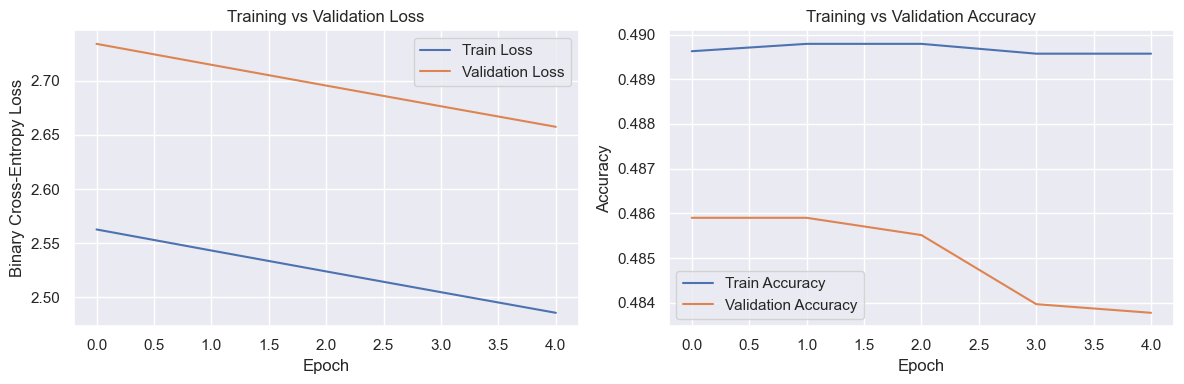

In [31]:
tf.random.set_seed(0)
# Build and compile model

model_tf = build_model(num_features=X_train_down.shape[1], learning_rate=0.0001)

# Fit the model

history = model_tf.fit(
    X_train_down, Y_train_down,
    epochs=5,
    batch_size=32,
    validation_data=(X_val, Y_val),
    verbose=1
)
# Generate (1,2) plot
plt.figure(figsize=(12, 4))

# Plot Loss
plt.subplot(1, 2, 1)
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Binary Cross-Entropy Loss")
plt.title("Training vs Validation Loss")
plt.legend()

# Plot Accuracy
plt.subplot(1, 2, 2)
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()

plt.tight_layout()
plt.show()

# Hyperparameter Tuning

Trial 4 Complete [00h 01m 14s]
val_loss: 0.7281121015548706

Best val_loss So Far: 0.6183761954307556
Total elapsed time: 00h 04m 59s
Best learning rate: 0.01


/opt/anaconda3/envs/ml-env/lib/python3.10/site-packages/keras/src/layers/core/dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


First five weights: [-0.0159047  -0.02824268 -0.05114755 -0.03937804 -0.07870819]
Bias term: -0.10770504176616669
Final train loss: 0.6199
Final val loss:   0.6173
Val - Train loss diff: -0.0025


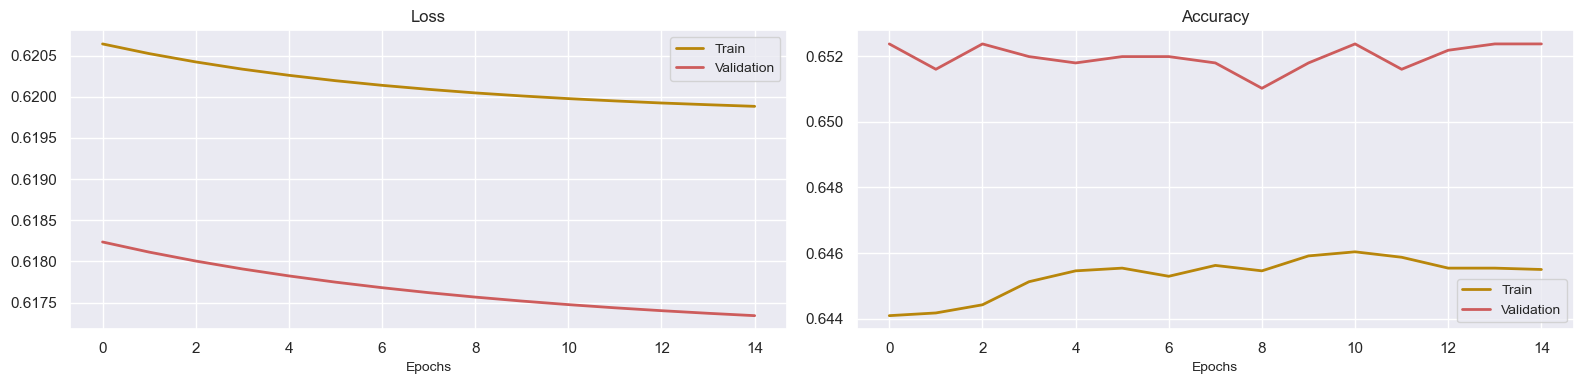

In [32]:
# 1) Define a tuner 
def build_model_tuner(hp):
    model = keras.Sequential()
    model.add(keras.layers.Dense(
        units=1,
        input_shape=(X_train.shape[1],),
        activation="sigmoid",
        use_bias=True,
        kernel_initializer= tf.keras.initializers.GlorotUniform(),
        bias_initializer= tf.zeros_initializer(),
    ))

    # Tune the learning rate
    lr = hp.Choice("learning_rate", [0.1, 1e-4, 1e-3, 1e-2])
    optimizer = keras.optimizers.SGD(learning_rate=lr)

    model.compile(optimizer=optimizer,
                  loss="binary_crossentropy",
                  metrics=["accuracy"])
    return model

# 2) Create tuner 
tuner = kt.RandomSearch(
    build_model_tuner,
    objective="val_loss",
    max_trials=5,
    overwrite=True,
    directory="w207_project",
    project_name="final_project"
)

# 3) Run tuner search
tuner.search(
    X_train, Y_train,
    validation_data=(X_val, Y_val),
    epochs=15,   
    verbose=1
)

# 4) Retrieve best hyperparameters and model
best_hp = tuner.get_best_hyperparameters(1)[0]
print("Best learning rate:", best_hp.get("learning_rate"))

best_model = tuner.get_best_models(1)[0]

# Re-train with best settings for clarity
history = best_model.fit(
    X_train, Y_train,
    validation_data=(X_val, Y_val),
    epochs=15,
    batch_size=32,
    verbose=0
)



# First five learned parameters (weights + bias)
W, b = best_model.layers[0].get_weights()
W = W.reshape(-1)
print("First five weights:", W[:5])
print("Bias term:", float(b[0]))

# Final-epoch loss on train and val
final_train_loss = history.history["loss"][-1]
final_val_loss   = history.history["val_loss"][-1]
print(f"Final train loss: {final_train_loss:.4f}")
print(f"Final val loss:   {final_val_loss:.4f}")

# 4) Difference between train and val
print(f"Val - Train loss diff: {final_val_loss - final_train_loss:.4f}")



#Plots
fig = plt.figure(figsize=(16, 4))

#loss
ax = fig.add_subplot(1, 2, 1)
plt.plot(history.history['loss'], lw=2, color='darkgoldenrod')
plt.plot(history.history['val_loss'], lw=2, color='indianred')
plt.legend(['Train', 'Validation'], fontsize=10)
ax.set_xlabel('Epochs', size=10)
ax.set_title('Loss')


#accuracy
ax = fig.add_subplot(1, 2, 2)
plt.plot(history.history['accuracy'], lw=2, color='darkgoldenrod')
plt.plot(history.history['val_accuracy'], lw=2, color='indianred')
plt.legend(['Train', 'Validation'], fontsize=10)
ax.set_xlabel('Epochs', size=10)
ax.set_title('Accuracy')


plt.tight_layout()
plt.show()


# Train, Val and Test Evaluation with The Best Model

## Train Evaluation

755/755 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


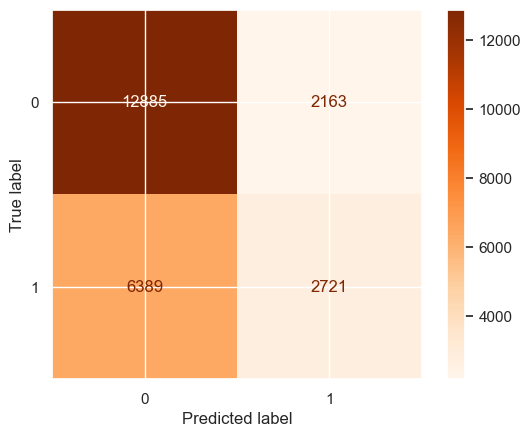

True_Positive: 2721 False_Negative: 6389 False_Positive: 2163 True_Negative: 12885
**************************************************
Train Set Performance and Confusion Matrix:
**************************************************
Risky Drinker Recall on Train Data:     0.2987
Non-Risky Drinker Recall on Train Data: 0.8563
Risky Drinker Precision on Train Data:     0.5571
Non-Risky Drinker Precision on Train Data: 0.6685
Risky F1 Score on Train Data:      0.3889
Non-Risky F1 Score on Train Data:      0.7508
Model Accuracy on Train Data:     0.6460
**************************************************


In [36]:
# Train predictions 
y_train_pred = (best_model.predict(X_train) >= 0.5).astype(int).ravel()
# Train cm
cm_train = sk_confusion_matrix(Y_train, y_train_pred)

ConfusionMatrixDisplay(confusion_matrix=cm_train).plot(cmap="Oranges")
plt.show()

tn_t, fp_t, fn_t, tp_t = cm_train.ravel()
print("True_Positive:", tp_t, "False_Negative:", fn_t, "False_Positive:", fp_t, "True_Negative:", tn_t)

risky_recall_train     = tp_t / (tp_t + fn_t) if (tp_t + fn_t) else 0.0
non_risky_recall_train = tn_t / (tn_t + fp_t) if (tn_t + fp_t) else 0.0

risky_precision_train =  tp_t / (tp_t + fp_t) if (tp_t + fp_t) else 0.0
non_risky_precision_train = tn_t / (tn_t + fn_t) if (tn_t + fn_t) else 0.0

f1_risky_train = 2*((risky_recall_train * risky_precision_train)/(risky_recall_train + risky_precision_train))
f1_non_risky_train = 2*((non_risky_recall_train * non_risky_precision_train)/(non_risky_recall_train + non_risky_precision_train))

model_acc_train     = (tp_t + tn_t) / (tn_t + fp_t + fn_t + tp_t) if (tn_t + fp_t + fn_t + tp_t) else 0.0

print('*' * 50)
print("Train Set Performance and Confusion Matrix:")
print('*' * 50)
print(f"Risky Drinker Recall on Train Data:     {risky_recall_train:.4f}")
print(f"Non-Risky Drinker Recall on Train Data: {non_risky_recall_train:.4f}")
print(f"Risky Drinker Precision on Train Data:     {risky_precision_train:.4f}")
print(f"Non-Risky Drinker Precision on Train Data: {non_risky_precision_train:.4f}")
print(f"Risky F1 Score on Train Data:      {f1_risky_train:.4f}")
print(f"Non-Risky F1 Score on Train Data:      {f1_non_risky_train:.4f}")
print(f"Model Accuracy on Train Data:     {model_acc_train:.4f}")
print('*' * 50)

## Val Evaluation

162/162 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


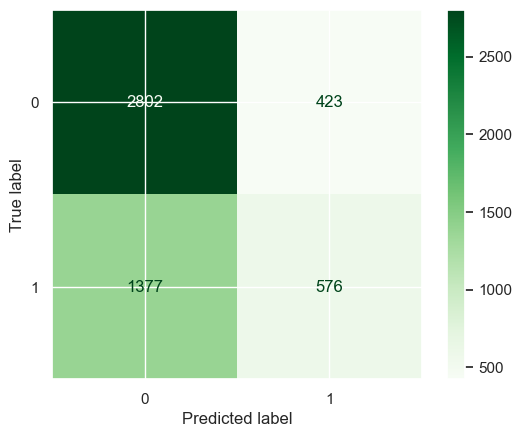

True_Positive: 576 False_Negative: 1377 False_Positive: 423 True_Negative: 2802
**************************************************
Val Set Performance and Confusion Matrix:
**************************************************
Risky Drinker Recall on Val Data:     0.2949
Non-Risky Drinker Recall on Val Data: 0.8688
Risky Drinker Precision on Val Data:     0.5766
Non-Risky Drinker Precision on Val Data: 0.6705
Risky F1 Score on Val Data:      0.3902
Non-Risky F1 Score on Val Data:      0.7569
Model Accuracy on Val Data:     0.6524
**************************************************


In [37]:
# Val predictions 
y_val_pred = (best_model.predict(X_val) >= 0.5).astype(int).ravel()
# Val cm
cm_val = sk_confusion_matrix(Y_val, y_val_pred)

ConfusionMatrixDisplay(confusion_matrix=cm_val).plot(cmap="Greens")
plt.show()

tn_v, fp_v, fn_v, tp_v = cm_val.ravel()
print("True_Positive:", tp_v, "False_Negative:", fn_v, "False_Positive:", fp_v, "True_Negative:", tn_v)

risky_recall_val     = tp_v / (tp_v + fn_v) if (tp_v + fn_v) else 0.0
non_risky_recall_val = tn_v / (tn_v + fp_v) if (tn_v + fp_v) else 0.0

risky_precision_val =  tp_v / (tp_v + fp_v) if (tp_v + fp_v) else 0.0
non_risky_precision_val = tn_v / (tn_v + fn_v) if (tn_v + fn_v) else 0.0

f1_risky_val = 2*((risky_recall_val * risky_precision_val)/(risky_recall_val + risky_precision_val))
f1_non_risky_val = 2*((non_risky_recall_val * non_risky_precision_val)/(non_risky_recall_val + non_risky_precision_val))

model_acc_val     = (tp_v + tn_v) / (tn_v + fp_v + fn_v + tp_v) if (tn_v + fp_v + fn_v + tp_v) else 0.0

print('*' * 50)
print("Val Set Performance and Confusion Matrix:")
print('*' * 50)
print(f"Risky Drinker Recall on Val Data:     {risky_recall_val:.4f}")
print(f"Non-Risky Drinker Recall on Val Data: {non_risky_recall_val:.4f}")
print(f"Risky Drinker Precision on Val Data:     {risky_precision_val:.4f}")
print(f"Non-Risky Drinker Precision on Val Data: {non_risky_precision_val:.4f}")
print(f"Risky F1 Score on Val Data:      {f1_risky_val:.4f}")
print(f"Non-Risky F1 Score on Val Data:      {f1_non_risky_val:.4f}")
print(f"Model Accuracy on Val Data:     {model_acc_val:.4f}")
print('*' * 50)

## Test Evaluation

162/162 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


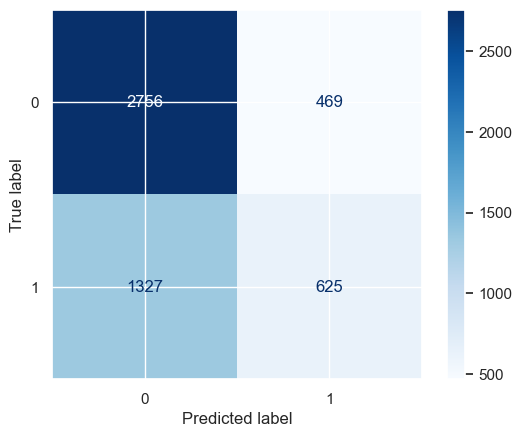

True_Positive: 625 False_Negative: 1327 False_Positive: 469 True_Negative: 2756
**************************************************
Test Set Performance and Confusion Matrix:
**************************************************
Risky Drinker Recall on Test Data:     0.3202
Non-Risky Drinker Recall on Test Data: 0.8546
Risky Drinker Precision on Test Data:     0.5713
Non-Risky Drinker Precision on Test Data: 0.6750
Risky F1 Score on Test Data:      0.3889
Non-Risky F1 Score on Test Data:      0.7508
Model Accuracy on Test Data:     0.6531
**************************************************


In [39]:

# Test predictions
y_pred = (best_model.predict(X_test) > 0.5).astype(int).ravel()
cm_test= sk_confusion_matrix(Y_test, y_pred)

ConfusionMatrixDisplay(confusion_matrix=cm_test).plot(cmap="Blues")
plt.show()

# test cm
tn, fp, fn, tp = cm_test.ravel()
print("True_Positive:", tp, "False_Negative:", fn, "False_Positive:", fp, "True_Negative:", tn)


risky_acc = tp / (tp + fn) if (tp + fn) > 0 else 0   
non_risky_acc = tn / (tn + fp) if (tn + fp) > 0 else 0

risky_recall_test    = tp / (tp + fn) if (tp + fn) else 0.0
non_risky_recall_test = tn / (tn + fp) if (tn + fp) else 0.0

risky_precision_test =  tp / (tp + fp) if (tp + fp) else 0.0
non_risky_precision_test = tn / (tn + fn) if (tn + fn) else 0.0

f1_risky_test = 2*((risky_recall_train * risky_precision_train)/(risky_recall_train + risky_precision_train))
f1_non_risky_test = 2*((non_risky_recall_train * non_risky_precision_train)/(non_risky_recall_train + non_risky_precision_train))

model_acc_test    = (tp + tn) / (tn + fp + fn + tp) if (tn + fp + fn + tp) else 0.0

print('*' * 50)
print("Test Set Performance and Confusion Matrix:")
print('*' * 50)
print(f"Risky Drinker Recall on Test Data:     {risky_recall_test:.4f}")
print(f"Non-Risky Drinker Recall on Test Data: {non_risky_recall_test:.4f}")
print(f"Risky Drinker Precision on Test Data:     {risky_precision_test:.4f}")
print(f"Non-Risky Drinker Precision on Test Data: {non_risky_precision_test:.4f}")
print(f"Risky F1 Score on Test Data:      {f1_risky_test:.4f}")
print(f"Non-Risky F1 Score on Test Data:      {f1_non_risky_test:.4f}")
print(f"Model Accuracy on Test Data:     {model_acc_test:.4f}")
print('*' * 50)






## ROC Curve

162/162 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Random: ROC AUC=0.500
Logistic: ROC AUC=0.681


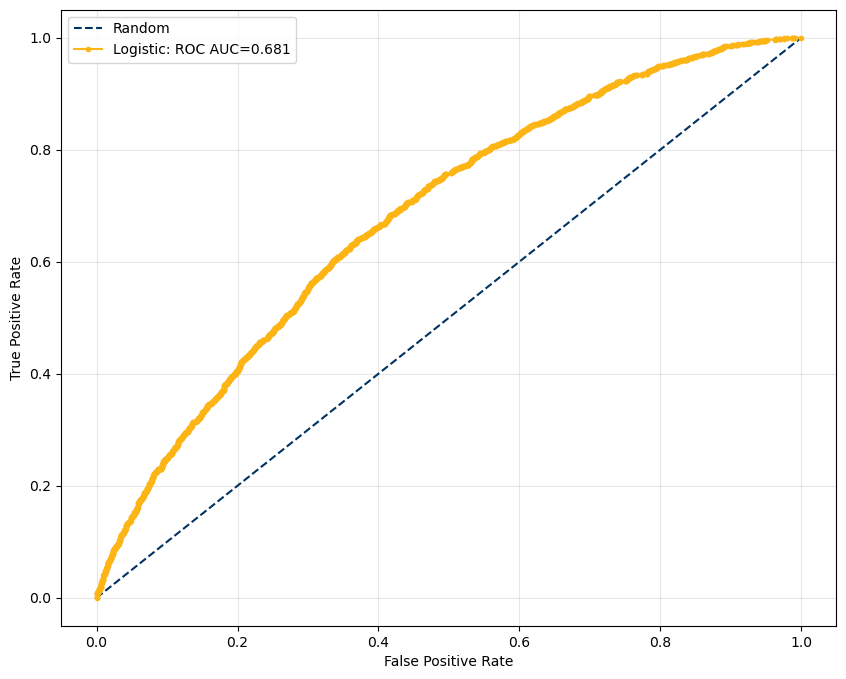

In [70]:
# predict probabilities
lr_probs = best_model.predict(X_test).ravel()
# generate a prediction (majority class)
ns_probs = [0 for _ in range(len(Y_test))]

# calculate scores
ns_auc = roc_auc_score(Y_test, ns_probs)
lr_auc = roc_auc_score(Y_test, lr_probs)

# summarize scores
print('Random: ROC AUC=%.3f' % (ns_auc))
print('Logistic: ROC AUC=%.3f' % (lr_auc))

# calculate roc curves
ns_fpr, ns_tpr, _ = roc_curve(Y_test, ns_probs)
lr_fpr, lr_tpr, _ = roc_curve(Y_test, lr_probs)

# plot the roc curve for the model
plt.figure(figsize=(10, 8))
plt.plot(ns_fpr, ns_tpr, linestyle='--', color='#003262', label='Random')
plt.plot(lr_fpr, lr_tpr, color='#FDB515', marker='.', label=f'Logistic: ROC AUC={lr_auc:.3f}')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.grid(alpha=0.3)
plt.legend()
plt.show()